# COVID-19 in Norway: A Case Study

**Norwegian Institute of Public Health (FolkeHelseInstituttet)** has published Norwegian surveillance data in a format that is easily accessible from a machine-reading perspective.  
🔗 [Surveillance Data Repository](https://github.com/folkehelseinstituttet/surveillance_data)  ⚠️ *The repository is now archived (set to read-only)*  


In this chapter, we use real COVID-19 data from the Norwegian Institute of Public Health (FHI) to explore disease spread and estimate the reproduction number $\mathcal{R}(t).$   
We then use these estimates in a SIRS compartmental model to simulate the epidemic under different scenarios.


## 1. Load Python packages

We begin by importing the necessary Python packages and ensuring required libraries are installed.


In [1]:
# --- Core packages ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
import requests

# --- Install optional packages if missing ---
try:
    from epyestim import covid19
except ImportError:
    !pip install epyestim pymc --quiet
    from epyestim import covid19


## 2. Load data from MSIS (Norwegian Institute of Public Health)
We use the dataset `data_covid19_msis_by_time_sex_age_latest.csv`, which includes weekly COVID-19 case counts in Norway by age and sex.

A short description of the data is in `_DOCUMENTATION_data_covid19_msis_by_time_sex_age.txt` can be also viewed for context.

In [2]:
url_msis="https://github.com/folkehelseinstituttet/surveillance_data/raw/master/covid19/data_covid19_msis_by_time_sex_age_latest.csv"

msis = pd.read_csv(url_msis) # Read the CSV file into a DataFrame
msis['date']=pd.to_datetime(msis.date) # convert date to datetime



doc_url = "https://raw.githubusercontent.com/folkehelseinstituttet/surveillance_data/master/covid19/_DOCUMENTATION_data_covid19_msis_by_time_sex_age.txt"

response = requests.get(doc_url) # Get the documentation 
documentation_text = response.text #Save the content as text

# To display the content, uncomment the line below
#print(documentation_text) # Print or display the content

msis.head() # Print the first few rows of the DataFrame


,granularity_time,granularity_geo,location_code,border,age,sex,year,week,yrwk,season,x,date,n,date_of_publishing
0,week,nation,norge,2020,0-9,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
1,week,nation,norge,2020,0-9,male,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
2,week,nation,norge,2020,10-19,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
3,week,nation,norge,2020,10-19,male,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
4,week,nation,norge,2020,20-29,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,1,2022-11-14


## 3. Explore the data
### 3.1. Summorize the data by age and sex


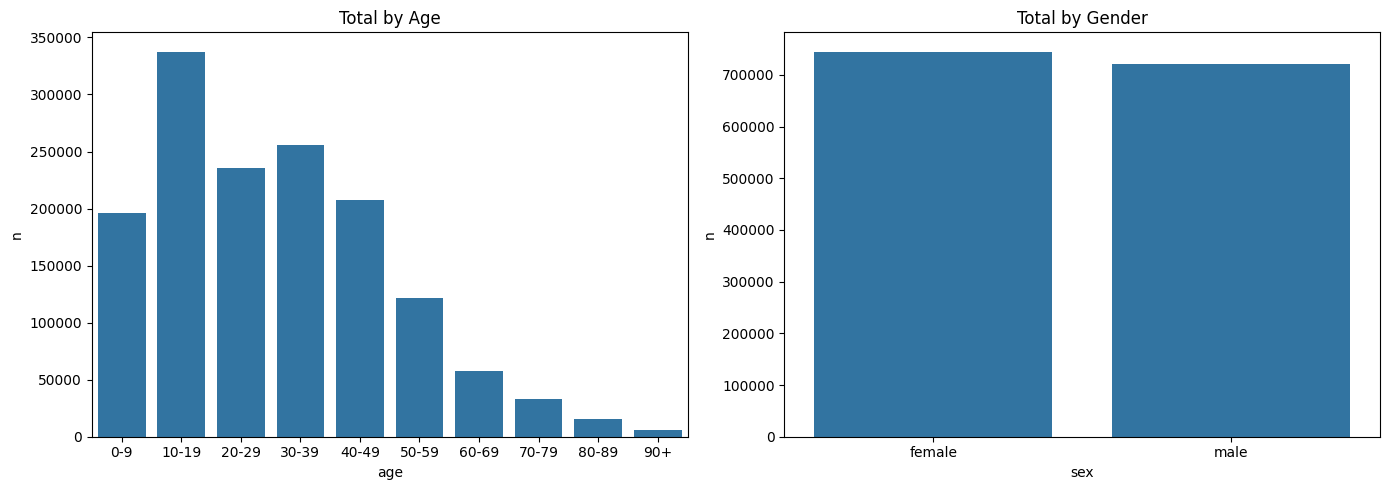

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=msis.groupby('age')['n'].sum().reset_index(), x='age', y='n', ax=ax[0])
sns.barplot(data=msis.groupby('sex')['n'].sum().reset_index(), x='sex', y='n', ax=ax[1])
ax[0].set_title("Total by Age"); ax[1].set_title("Total by Gender")
plt.tight_layout()
plt.show()

### 3.2. Visualize time series
We visualize case counts by age and sex on linear and logarithmic scales.

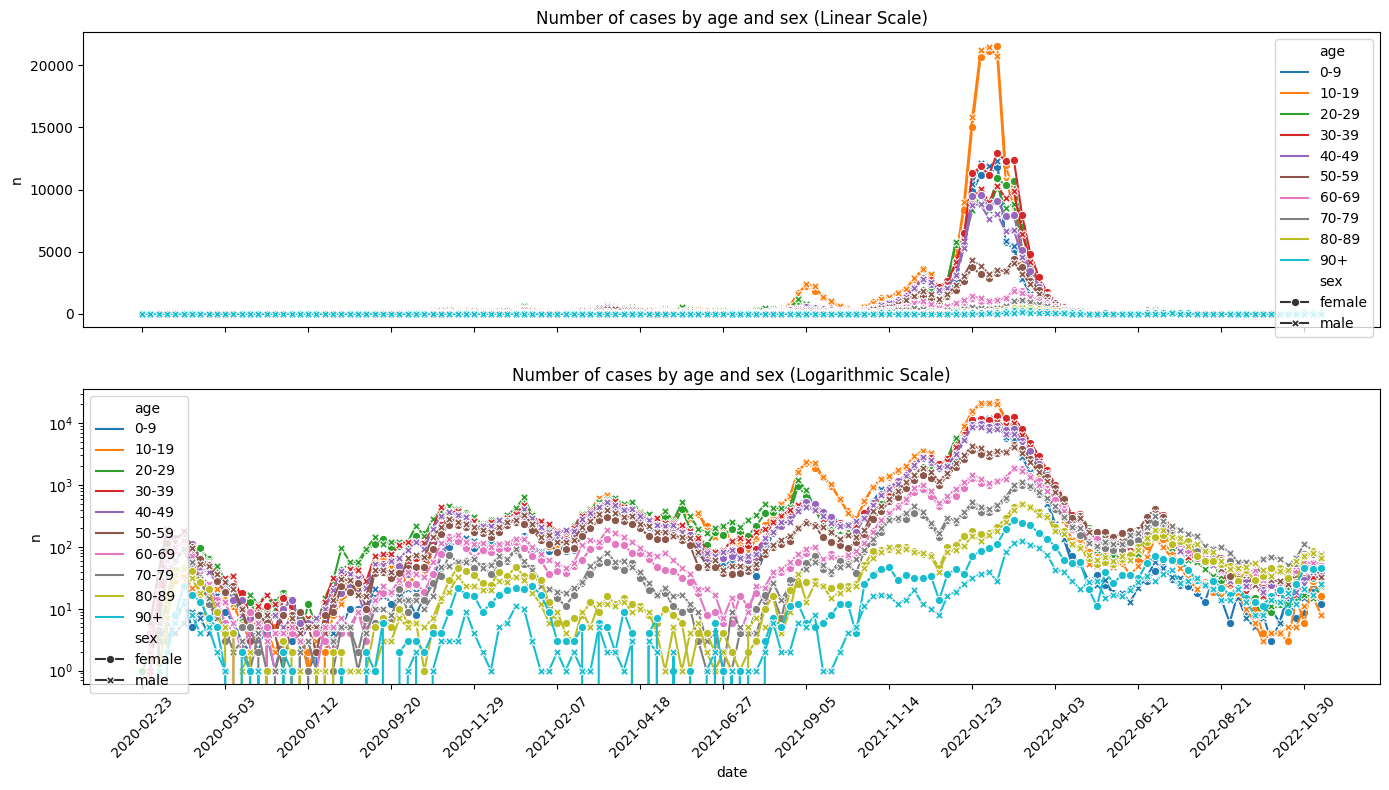

In [4]:

# Create the subplots with shared x-axis
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# First subplot: Linear scale
sns.lineplot(
    data=msis,
    x='date',
    y='n',
    hue='age',
    style='sex',
    markers=True,
    dashes=False,
    ax=ax[0]
)
ax[0].set_title('Number of cases by age and sex (Linear Scale)')

# Second subplot: Logarithmic scale
sns.lineplot(
    data=msis,
    x='date',
    y='n',
    hue='age',
    style='sex',
    markers=True,
    dashes=False,
    ax=ax[1]
)
ax[1].set_yscale('log')  # Set y-axis to log scale
ax[1].set_title('Number of cases by age and sex (Logarithmic Scale)')


# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Reduce the number of x-axis ticks by showing every Nth tick
N = 10  # Adjust N as needed
xticks = msis['date'].unique()[::N]
ax[1].set_xticks(xticks)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()




### 3.3. Aggregate all the cases
Next, we combine all the data to calculte all cases across age and gender:

In [5]:
# Group by date and sum the cases
weekly_cases = msis.groupby('date', as_index=False)['n'].sum().set_index('date')
weekly_cases.head()

,n
date,
2020-02-23,1
2020-03-01,30
2020-03-08,217
2020-03-15,1215
2020-03-22,1438


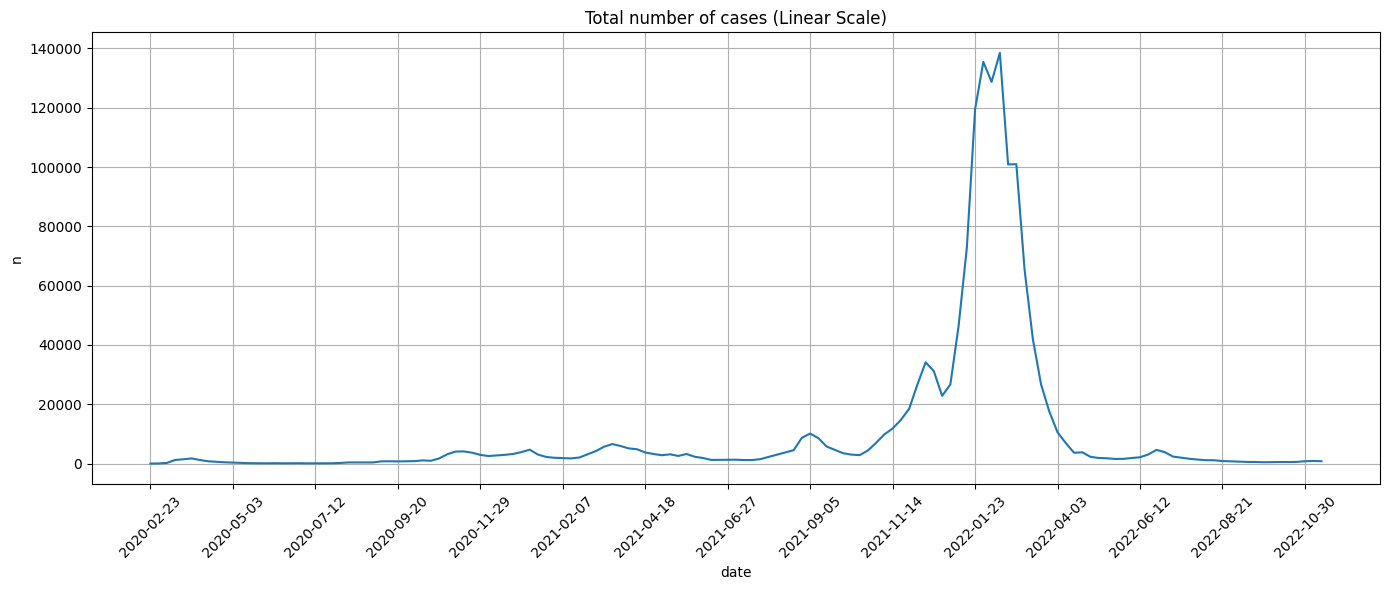

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=weekly_cases,
    x=weekly_cases.index,
    y='n',
    ax=ax
)

ax.set_title('Total number of cases (Linear Scale)')


# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Reduce the number of x-axis ticks by showing every Nth tick
N = 10  # Adjust N as needed
xticks = weekly_cases.index[::N]
ax.set_xticks(xticks)
ax.grid(True)  # Add grid to the first subplot

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()


## 5. Estimate Reproduction Number $R(t)$

We estimate the effective reproduction number $\mathcal{R}(t)$ using the Python package [`epyestim`](https://github.com/lo-hfk/epyestim), which is based on Bayesian inference for time-varying reproduction numbers.

The method uses:
- A smoothed time series of daily incidence data
- A serial interval distribution (i.e., time between successive cases)
- A delay distribution between infection and case reporting

`epyestim` accounts for uncertainty and returns quantiles (e.g., 2.5%, 97.5%) as well as the posterior mean of $\mathcal{R}(t)$.  
These estimates are crucial for evaluating when transmission is increasing ($R(t) > 1$) or under control ($R(t) < 1$).

We apply it to the interpolated case data from MSIS.



In [7]:
import epyestim.covid19 as covid19

daily_cases = weekly_cases.resample('D').interpolate(method='linear') #interolate data to daily cases
r_estimates = covid19.r_covid(daily_cases['n'])
r_estimates.head()

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2020-02-28,21.0,4.867619,0.036538,4.499055,4.865096,5.250110
2020-02-29,25.0,3.410986,0.014867,3.176803,3.409525,3.654050
2020-03-01,30.0,2.633883,0.007466,2.466540,2.632938,2.806603
2020-03-02,56.0,2.306743,0.004717,2.173656,2.306069,2.443583
2020-03-03,83.0,2.245974,0.003537,2.130281,2.245443,2.364592


We can now plot the obtained estimated $R(t)$ the  $97.5\%$ confidence interval of the estimate. 

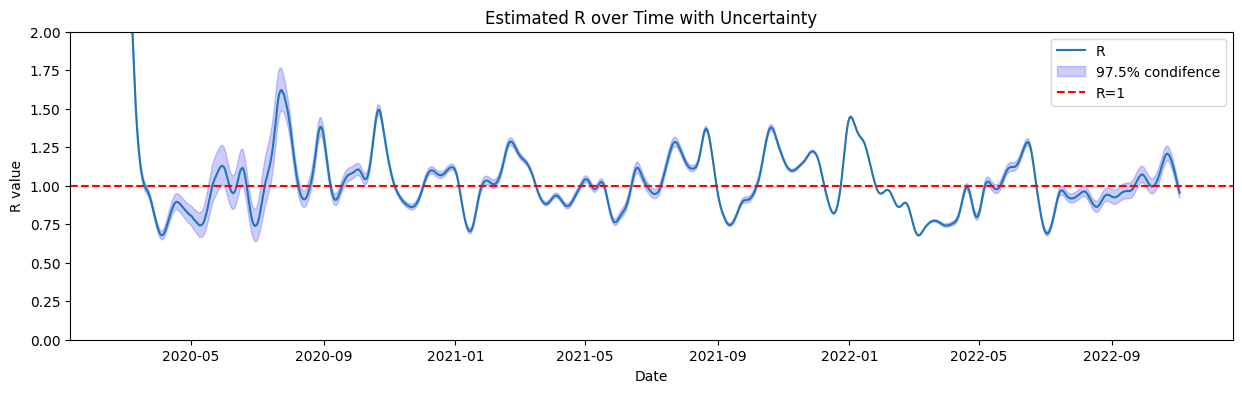

In [8]:
# Plot the R estimates with uncertainty
fig, ax = plt.subplots(figsize=(15, 4))
sns.lineplot(data=r_estimates, x=r_estimates.index, y='R_mean', ax=ax, label='R')
ax.fill_between(r_estimates.index, r_estimates['Q0.025'], r_estimates['Q0.975'], color='b', alpha=0.2, label='97.5% condifence')
ax.axhline(y=1, color='r', linestyle='--', label='R=1')
ax.set_xlabel('Date')
ax.set_ylabel('R value')
ax.set_title('Estimated R over Time with Uncertainty')

# uncomment the following lines to set x-axis limits
#start_date, end_date= pd.to_datetime('2020-04-01'), pd.to_datetime('2020-09-01')
#ax.set_xlim(start_date, end_date)
ax.set_ylim(0, 2)
ax.legend()
plt.show()

## 6. SIRS Model with Time-Varying Reproduction Number $\mathcal{R}(t)$

In this section, we define and solve a **SIRS model** where the effective reproduction number $\mathcal{R}(t)$ varies with time, based on the estimate above.

### Model Overview

The model follows the classic SIRS dynamics with compartments:
- $S(t)$: susceptible individuals  
- $I(t)$: infected individuals  
- $R(t)$: recovered (and temporarily immune) individuals

We incorporate $\mathcal{R}(t)$ directly into the model using a time-dependent transmission rate:

$$
\beta(t) = \gamma  \mathcal{R}(t)
$$

This requires interpolating $\mathcal{R}(t)$  values at arbitrary time points using the `R_interp` function.

###  Model Equations

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta(t)  \frac{S I}{N} + \eta R \\
\frac{dI}{dt} &= \beta(t)  \frac{S I}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I - \eta R
\end{aligned}
$$

###  Parameters

| Symbol  | Meaning                         | Value         |
|---------|----------------------------------|---------------|
| $\gamma$ | Recovery rate                  | $1/7$ (1 infection lasts ~7 days) |
| $\eta$   | Loss of immunity rate         | $1/30$ (immunity lasts ~30 days) |
| $N$      | Total population              | 5,400,000     |
| $\mathcal{R}(t)$   | Time-varying reproduction number | Estimated from data |
| $I_0$    | Initial infected individuals   | From case data on the first date |
| $S_0, R_0$ | Initial susceptible/recovered | Computed from $N$ and $I_0$ |

###  Initial Setup

We define:
- `R_interp(t, Rt, key)`: interpolates the $R(t)$ values for continuous time
- `deriv(...)`: defines the SIRS differential equations with $\beta(t)$
- Time grid $t$: in days since the start (can be selected within the range of estimated $\mathcal{R}(t)$) 

This setup is then passed to the `odeint` solver to simulate the SIRS model.


In [9]:
def R_interp(t, Rt, key):
    """
    Interpolates the R values for the given time points.
    str ='R_mean' or 'Q0.975' or 'Q0.025'
    t: Time points for interpolation, in days since the start date refereced to in Rt.index[0]
    """
    days =(Rt.index - Rt.index[0]).days
    R_values = np.interp(t, days, Rt[key])
    return R_values

def deriv(X, t, N, gamma, eta, Rt, key ='R_mean'):
    """
    Compute the derivatives for the SIR model, with estimated R(t) values.
    For the odeint solver to work, we interpolate the R values for the time points, see R_interp function.
    """
    S, I, R = X
    beta =  R_interp(t,Rt,key)*gamma
    dSdt = -beta * S * I / N + eta*R
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I - eta*R
    return dSdt, dIdt, dRdt

#Define the parameters
gamma, eta = 1/7, 1/30
N = 5_400_000
day0, dayN = r_estimates.index[14], r_estimates.index[-1] 
Rt = r_estimates.loc[day0:dayN]
t = np.linspace(0, (dayN - day0).days, (dayN - day0).days + 1)
I0 = daily_cases.loc[day0]['n']
X0 = N - I0, I0, 0
 
print('The model is initialized...')      

The model is initialized...


### 6.1. Run the numerical simulations 
Run the code using mean estimate $\mathcal{R}(t)$ and its $97.5\%$ quantiles.

In [10]:
SIR_dict = {}


for key in ['R_mean', 'Q0.025', 'Q0.975']:
    ret = odeint(deriv, X0, t, args=(N, gamma, eta, Rt, key))
    SIR_dict['S for ' + key] = ret.T[0]
    SIR_dict['I for ' + key] = ret.T[1]
    SIR_dict['R for ' + key] = ret.T[2]

SIR = pd.DataFrame(SIR_dict, index=t)
SIR.head()

,S for R_mean,I for R_mean,R for R_mean,S for Q0.025,I for Q0.025,R for Q0.025,S for Q0.975,I for Q0.975,R for Q0.975
0.0,5.399070e+06,929.857143,0.000000,5.399070e+06,929.857143,0.000000,5.399070e+06,929.857143,0.000000
1.0,5.398903e+06,964.052258,133.173067,5.398908e+06,959.446780,132.847328,5.398898e+06,968.733541,133.503699
2.0,5.398745e+06,989.354879,266.143434,5.398755e+06,980.222857,264.860162,5.398734e+06,998.678752,267.449828
3.0,5.398595e+06,1006.900200,397.748358,5.398612e+06,993.392837,394.912895,5.398579e+06,1020.754735,400.643670
4.0,5.398455e+06,1017.943035,527.028601,5.398478e+06,1000.234975,522.089612,5.398432e+06,1036.192123,532.087494


### 6.2. Plot the results 



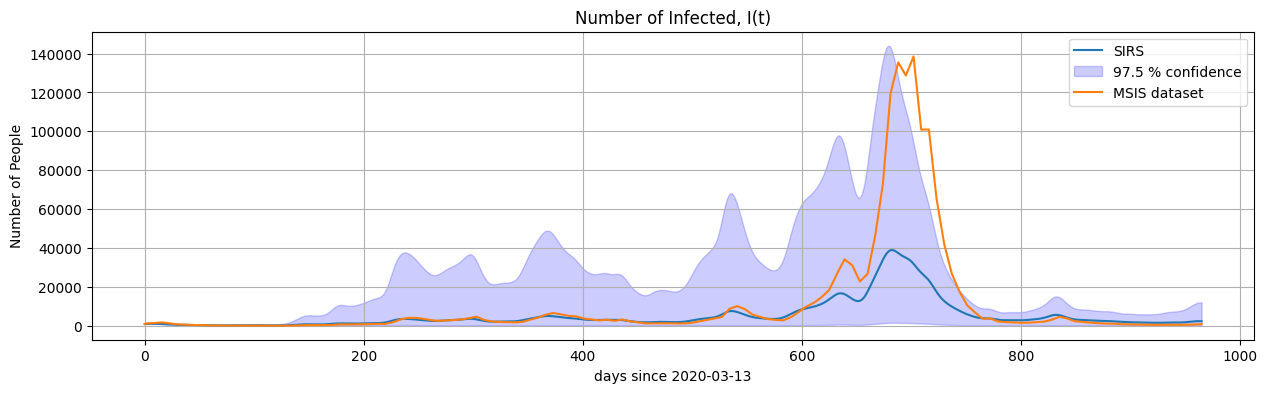

In [11]:
fig, ax = plt.subplots(figsize=(15, 4))
sns.lineplot(data=SIR, x=SIR.index, y='I for R_mean', ax=ax, label='SIRS')
ax.fill_between(SIR.index, SIR['I for Q0.025'], SIR['I for Q0.975'], color='b', alpha=0.2, label='97.5 % confidence')

sns.lineplot(data=daily_cases.loc[day0:dayN], x=SIR.index, y='n', ax=ax, label='MSIS dataset')


ax.set_xlabel('days since ' + str(day0.date())) 
ax.set_ylabel('Number of People') 
ax.set_title('Number of Infected, I(t)')
ax.legend()

plt.grid(True)
plt.show()

## 7. Real-World Considerations and Model Limitations

In this example, the reported COVID-19 case data have been used both to estimate the time-varying reproduction number $\mathcal{R}(t)$ and to evaluate the fit of the SIRS model to observed dynamics. As a result, it is not surprising that the model qualitatively matches the data relatively well. The simulation is based on information derived from the same data it is compared against.

### Important considerations

- The true value of $\mathcal{R}(t)$ is not directly observable and must be estimated from imperfect and delayed data sources.
- Reported case numbers depend on factors such as testing capacity, case definitions, reporting delays, and public health policies.
- The model does not include important real-world factors such as vaccination, public behavior changes, or non-pharmaceutical interventions (e.g., lockdowns or mask mandates).
- The SIRS model used here assumes a homogeneously mixing population, constant recovery and reinfection rates, and does not include age structure, geography, or other heterogeneities.

### Conclusion

Mathematical models are simplified representations of complex systems. They are valuable for exploring hypotheses and testing possible scenarios, but they cannot account for every aspect of a real-world epidemic.

### Exploration

Now that the basic SIRS model has been implemented and compared with data, you are encouraged to explore further. Try the following:

#### Vary the model parameters

- What happens if the recovery rate $\gamma$ is increased or decreased?
- How does the duration of immunity (controlled by $\eta$) affect the long-term dynamics?
- Try different values of the initial conditions $I_0$, $R_0$, and see how they change the peak and timing of infections.

#### Extend the model structure

- Implement an SIERS model by adding an "Exposed" compartment for individuals who are infected but not yet infectious.
- Add age structureand and/ore explore model with vaccination, the vaccination data can be obtaind  from 🔗 [Surveillance Data Repository](https://github.com/folkehelseinstituttet/surveillance_data)  
- Explore how different vaccination rates or timings change the spread of the disease.


---

Exploring these extensions will help deepen your understanding of epidemic modeling and the role of mathematical assumptions in interpreting public health data.


